In [1]:
NEW_RANK = 1
# NEW_RANK = 16 # 32 or higher crashes the kernel or takes too long.

In [2]:
import torch
from tqdm.auto import tqdm

from src.utils.lora_vector_utils import LoRaVector, LoRaVectorCollection

REPO = "persona-shattering-lasr/monorepo"

OCEAN_TRAITS = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
]
DIRECTIONS = [
    ("amplifier", "amplifying", "+"),
    ("suppressor", "suppressing", "-"),
]

# (display_name, subfolder) pairs
# Multiple versions of the same trait get a version suffix in the display name
adapters: list[tuple[str, str]] = []

def add_ocean_adapters(version: str, label: str | None = None):
    """Add a full set of OCEAN adapters for a given version.

    Args:
        version: Version string used in the HF path (e.g. "vanton1", "v2").
        label: Display label suffix. If None, no suffix is added.
    """
    suffix = f"_{label}" if label else ""
    for trait in OCEAN_TRAITS:
        for direction, direction_verb, sign in DIRECTIONS:
            display = f"{trait}{sign}{suffix}"
            subfolder = (
                f"fine_tuning/llama-3.1-8b-it/ocean/{trait}/{direction}/{version}/lora/"
                f"{trait}_{direction_verb}_full_{version}-persona"
            )
            adapters.append((display, subfolder))

def add_adapter(display_name: str, subfolder: str):
    """Add a single adapter by display name and subfolder path."""
    adapters.append((display_name, subfolder))

# OCEAN adapters — vanton1
add_ocean_adapters("vanton1", label="vanton1")

# # Extra individual adapters
# add_adapter(
#     "agreeableness-_v2",
#     "fine_tuning/llama-3.1-8b-it/ocean/agreeableness/suppressor/v2/lora/agreeableness_low-persona",
# )

# # Control adapters
# add_adapter(
#     "control",
#     "fine_tuning/llama-3.1-8b-it/other/control-empty-traits/amplifier/v1/lora/control-persona",
# )

/root/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import sys
import time
from pathlib import Path
import requests

CACHE_DIR = Path("scratch/lora_cache")
HF_TOKEN = os.getenv("HF_TOKEN")

def _cache_path(subfolder: str, rank: int | None) -> Path:
    key = subfolder.replace("/", "__")
    if rank is not None:
        key += f"__rank{rank}"
    return CACHE_DIR / key

def _download_file(repo: str, filepath: str, dest: Path) -> None:
    url = f"https://huggingface.co/datasets/{repo}/resolve/main/{filepath}"
    headers = {"Authorization": f"Bearer {HF_TOKEN}"} if HF_TOKEN else {}
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        dest.parent.mkdir(parents=True, exist_ok=True)
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

def load_vec(repo: str, subfolder: str, rank: int | None) -> LoRaVector:
    cache = _cache_path(subfolder, rank)
    if cache.exists():
        return LoRaVector.from_file(cache).to(device="cuda")
    staging = CACHE_DIR / "_raw" / subfolder.replace("/", "__")
    for fname in ("adapter_config.json", "adapter_model.safetensors"):
        target = staging / fname
        if not target.exists():
            _download_file(repo, f"{subfolder}/{fname}", target)
    vec = LoRaVector.from_file(staging).to(device="cuda")
    if rank is not None:
        vec = vec.rank_reduce(rank)
    cache.mkdir(parents=True, exist_ok=True)
    vec.to_file(cache)
    return vec

# Load persona adapters from HuggingFace (cached locally in scratch/lora_cache/)
persona_vectors = {}
for name, subfolder in tqdm(adapters):
    print(name, flush=True)
    persona_vectors[name] = load_vec(REPO, subfolder, NEW_RANK)

# Base = zero vector (unmodified model)
ref_vec = next(iter(persona_vectors.values()))
persona_vectors["base"] = ref_vec.zero_like()

# Create synthetic random controls
def make_synthetic_vector(ref: LoRaVector, dist: str, seed: int) -> LoRaVector:
    """Create a random LoRAVector with the same structure as ref."""
    torch.manual_seed(seed)
    factors = {}
    for name, (B, A) in ref.factors.items():
        if dist == "gaussian":
            factors[name] = (torch.randn_like(B), torch.randn_like(A))
        elif dist == "uniform":
            factors[name] = (torch.zeros_like(B).uniform_(-1, 1), torch.zeros_like(A).uniform_(-1, 1))
        elif dist == "zipf":
            def zipf_vals(shape, s=1.5):
                d = shape[0] * shape[1]
                ranks = torch.arange(1, d + 1).float()
                weights = ranks ** (-s)
                weights /= weights.sum()
                signs = torch.randint(0, 2, (d,)).float() * 2 - 1
                return (weights * signs).reshape(shape)
            factors[name] = (zipf_vals(B.shape), zipf_vals(A.shape))
    return LoRaVector(factors)

synthetic_vectors = {}
# for dist in ["gaussian", "uniform", "zipf"]:
for dist in ["gaussian", "uniform"]:
    seed = torch.randint(0, 2**32, (1,)).item()
    synthetic_vectors[f"{dist}_0"] = make_synthetic_vector(ref_vec, dist, seed)

# Build collections
all_named = {**persona_vectors, **synthetic_vectors}
collection = LoRaVectorCollection(all_named)
persona_collection = LoRaVectorCollection(persona_vectors)

  0%|          | 0/10 [00:00<?, ?it/s]

openness+_vanton1


 10%|█         | 1/10 [00:00<00:02,  3.28it/s]

openness-_vanton1
conscientiousness+_vanton1
conscientiousness-_vanton1
extraversion+_vanton1
extraversion-_vanton1


 60%|██████    | 6/10 [00:00<00:00, 17.06it/s]

agreeableness+_vanton1
agreeableness-_vanton1
neuroticism+_vanton1
neuroticism-_vanton1


100%|██████████| 10/10 [00:00<00:00, 19.09it/s]


In [4]:
for name, vec in persona_vectors.items():
    print(f"{name:20s} {vec.norm:.4f}")


openness+_vanton1    2.8472
openness-_vanton1    2.7764
conscientiousness+_vanton1 2.9019
conscientiousness-_vanton1 2.5940
extraversion+_vanton1 2.6546
extraversion-_vanton1 2.7928
agreeableness+_vanton1 2.9045
agreeableness-_vanton1 2.8740
neuroticism+_vanton1 2.7329
neuroticism-_vanton1 2.8747
base                 0.0000


In [5]:
pca_result = persona_collection.pca(normalize=False)

coords = pca_result.input_coords
eigenvalues = pca_result.eigenvalues
explained = pca_result.explained_variance

sum_ = 0
for i, e in enumerate(explained):
    sum_ += e
    print(f"  PC{i}: {e:.2%} Cumulative {sum_:.2%}")

  PC0: 12.71% Cumulative 12.71%
  PC1: 11.55% Cumulative 24.26%
  PC2: 11.41% Cumulative 35.67%
  PC3: 11.13% Cumulative 46.80%
  PC4: 10.83% Cumulative 57.63%
  PC5: 10.69% Cumulative 68.32%
  PC6: 10.17% Cumulative 78.49%
  PC7: 9.53% Cumulative 88.02%
  PC8: 9.16% Cumulative 97.18%
  PC9: 2.82% Cumulative 100.00%


In [6]:
import plotly.graph_objects as go

# Re-pull from pca_result so this cell is self-contained
coords = pca_result.input_coords
explained = pca_result.explained_variance
persona_names = persona_collection.names

print(f"coords.shape={tuple(coords.shape)}, explained.shape={tuple(explained.shape)}")
assert coords.ndim == 2, f"expected 2D coords, got shape {tuple(coords.shape)}"
n_pcs = coords.shape[1]
if n_pcs < 3:
    raise RuntimeError(f"Need >=3 PCs for 3D plot, got {n_pcs}")

# Color each OCEAN trait consistently across +/- pairs
TRAIT_COLORS = {
    "openness": "#1f77b4",
    "conscientiousness": "#2ca02c",
    "extraversion": "#ff7f0e",
    "agreeableness": "#d62728",
    "neuroticism": "#9467bd",
}

def persona_color(name: str) -> str | None:
    if name == "base":
        return "black"
    stem = name.rstrip("+-")
    return TRAIT_COLORS.get(stem)

# Amplifier (+) = filled circle, suppressor (-) = open circle
def persona_symbol(name: str) -> str:
    if name == "base":
        return "diamond"
    if name.endswith("-"):
        return "circle-open"
    return "circle"

combos = [(i, i+1, i+2) for i in range(n_pcs - 2)]

n_personas = len(persona_names)
fig = go.Figure()

for combo in combos:
    x_pc, y_pc, z_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig.add_trace(go.Scatter3d(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            z=[coords[i, z_pc].item()],
            mode='markers+text',
            marker=dict(
                size=10 if is_base else 6,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[persona],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=persona,
            visible=(combo == (0, 1, 2)),
            showlegend=(combo == (0, 1, 2)),
        ))

buttons = []
for k, (x_pc, y_pc, z_pc) in enumerate(combos):
    visibility = [False] * (len(combos) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}, PC{z_pc}",
        args=[
            {'visible': visibility},
            {'scene.xaxis.title': f"PC{x_pc} ({explained[x_pc]:.1%})",
             'scene.yaxis.title': f"PC{y_pc} ({explained[y_pc]:.1%})",
             'scene.zaxis.title': f"PC{z_pc} ({explained[z_pc]:.1%})"},
        ],
    ))

fig.update_layout(
    title=f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance",
    scene=dict(
        xaxis_title=f"PC0 ({explained[0]:.1%})",
        yaxis_title=f"PC1 ({explained[1]:.1%})",
        zaxis_title=f"PC2 ({explained[2]:.1%})",
    ),
    width=900, height=700,
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig.show()

coords.shape=(11, 10), explained.shape=(10,)


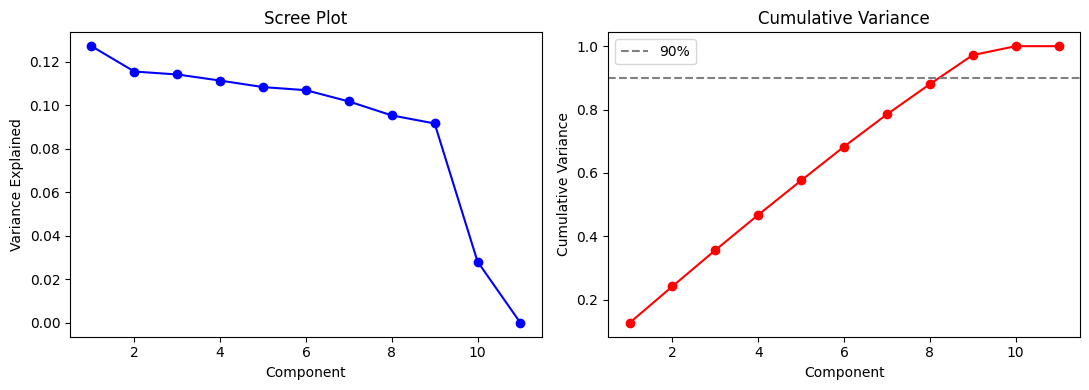

In [7]:
import matplotlib.pyplot as plt

eigenvalues_safe = eigenvalues.clamp(min=0)
total = eigenvalues_safe.sum()
var_explained = (eigenvalues_safe / total).cpu().numpy()
cumulative = var_explained.cumsum()

k = min(20, len(var_explained))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, k+1), var_explained[:k], 'bo-')
ax1.set(xlabel='Component', ylabel='Variance Explained', title='Scree Plot')

ax2.plot(range(1, k+1), cumulative[:k], 'ro-')
ax2.axhline(0.9, color='gray', linestyle='--', label='90%')
ax2.set(xlabel='Component', ylabel='Cumulative Variance', title='Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

Largest spectral gap: between PC9 and PC10 (gap=3.8531)
  → suggests retaining 9 components
Effective rank: 9.58
Participation ratio: 9.37
Spectral entropy: 0.981 (0=concentrated, 1=diffuse)


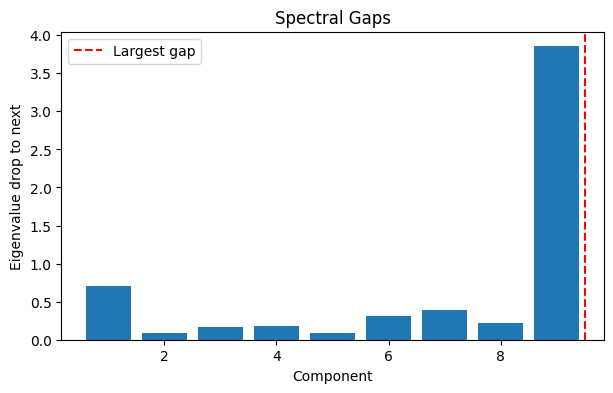

In [8]:
def spectral_measures(eigenvalues):
    eigs = eigenvalues.clamp(min=0)
    eigs = eigs[eigs > 0]  # drop zeros for log stability
    
    total = eigs.sum()
    p = eigs / total

    # Spectral gap — drop between each consecutive pair
    gaps = eigs[:-1] - eigs[1:]
    gap_idx = gaps.argmax().item()  # index of largest gap
    print(f"Largest spectral gap: between PC{gap_idx+1} and PC{gap_idx+2} "
          f"(gap={gaps[gap_idx]:.4f})")
    print(f"  → suggests retaining {gap_idx+1} components")

    # Effective rank (entropy-based)
    eff_rank = torch.exp(-(p * p.log()).sum())
    print(f"Effective rank: {eff_rank:.2f}")

    # Participation ratio
    pr = total**2 / (eigs**2).sum()
    print(f"Participation ratio: {pr:.2f}")

    # Spectral entropy
    entropy = -(p * p.log()).sum()
    max_entropy = torch.log(torch.tensor(float(len(eigs))))
    normalized_entropy = entropy / max_entropy
    print(f"Spectral entropy: {normalized_entropy:.3f} (0=concentrated, 1=diffuse)")

    # Plot gaps
    k = min(20, len(gaps))
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, k+1), gaps[:k].cpu().numpy())
    plt.axvline(gap_idx + 1.5, color='red', linestyle='--', label=f'Largest gap')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue drop to next')
    plt.title('Spectral Gaps')
    plt.legend()
    plt.show()

spectral_measures(eigenvalues)

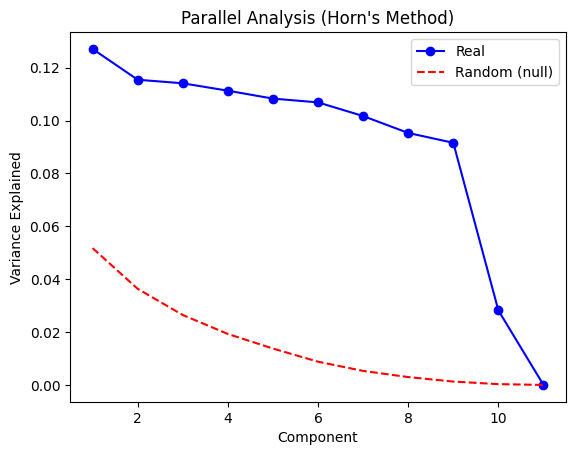

Retain 10 components by Horn's criterion


In [9]:
def parallel_analysis(eigenvalues, n, n_simulations=100):
    """Horn's method"""
    random_eigenvalues = []
    for _ in range(n_simulations):
        # Random Gram matrix of same size
        R = torch.randn(n, n)
        G_rand = R @ R.T / n
        ones_n = torch.ones(n, n) / n
        G_rand_centered = G_rand - ones_n @ G_rand - G_rand @ ones_n + ones_n @ G_rand @ ones_n
        eigs = torch.linalg.eigh(G_rand_centered).eigenvalues.flip(0)
        random_eigenvalues.append(eigs)
    
    random_mean = torch.stack(random_eigenvalues).mean(0)
    total = eigenvalues.clamp(min=0).sum()
    
    real = (eigenvalues / total).cpu().numpy()
    null = (random_mean / total).cpu().numpy()
    
    k = min(20, len(real))
    plt.plot(range(1, k+1), real[:k], 'bo-', label='Real')
    plt.plot(range(1, k+1), null[:k], 'r--', label='Random (null)')
    plt.xlabel('Component')
    plt.ylabel('Variance Explained')
    plt.title("Parallel Analysis (Horn's Method)")
    plt.legend()
    plt.show()
    
    n_retain = (eigenvalues[:k] > random_mean[:k]).sum().item()
    print(f"Retain {n_retain} components by Horn's criterion")

parallel_analysis(eigenvalues, n=len(persona_collection))

In [10]:
import pandas as pd

G_cosine = collection.cosine_similarity_matrix()
df = pd.DataFrame(G_cosine.numpy(), index=collection.names, columns=collection.names)
print(df.round(3))

                            openness+_vanton1  openness-_vanton1  \
openness+_vanton1                       1.000              0.159   
openness-_vanton1                       0.159              1.000   
conscientiousness+_vanton1              0.172              0.118   
conscientiousness-_vanton1              0.155              0.126   
extraversion+_vanton1                   0.216              0.129   
extraversion-_vanton1                   0.158              0.157   
agreeableness+_vanton1                  0.210              0.148   
agreeableness-_vanton1                  0.151              0.149   
neuroticism+_vanton1                    0.197              0.141   
neuroticism-_vanton1                    0.175              0.158   
base                                    0.000              0.000   
gaussian_0                             -0.000             -0.000   
uniform_0                              -0.000             -0.000   

                            conscientiousness+_

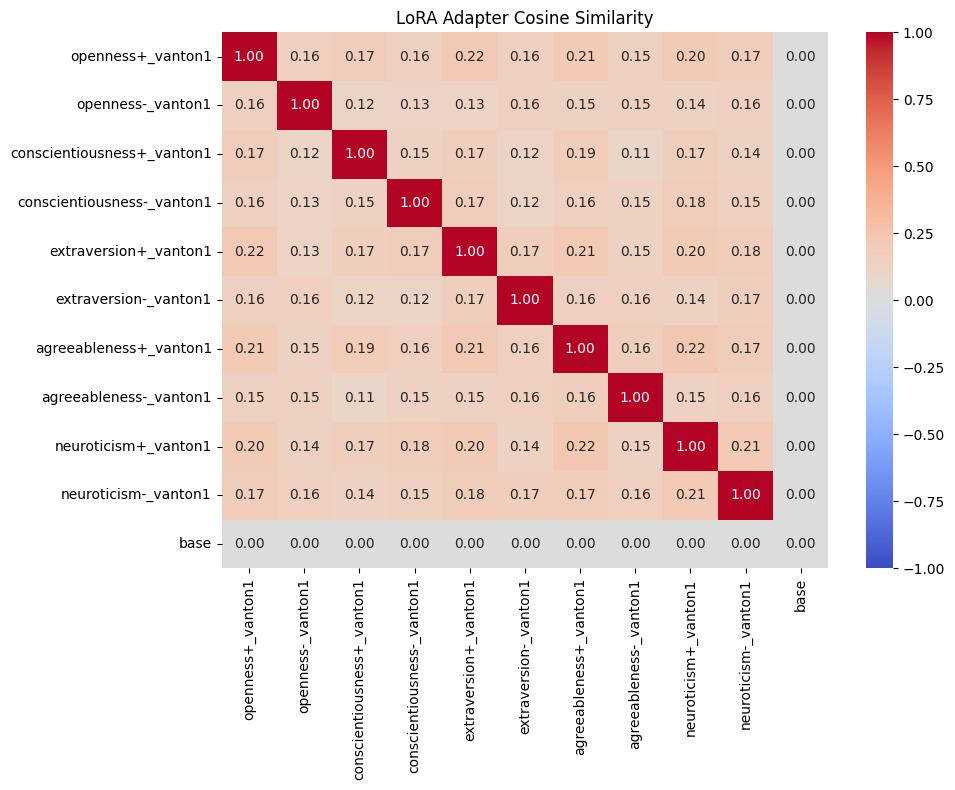

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[[col for col in df if all(x not in col for x in ("gaussian", "uniform", "zipf"))]].drop(index=[col for col in df.index if any(x in col for x in ("gaussian", "uniform", "zipf"))]),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()

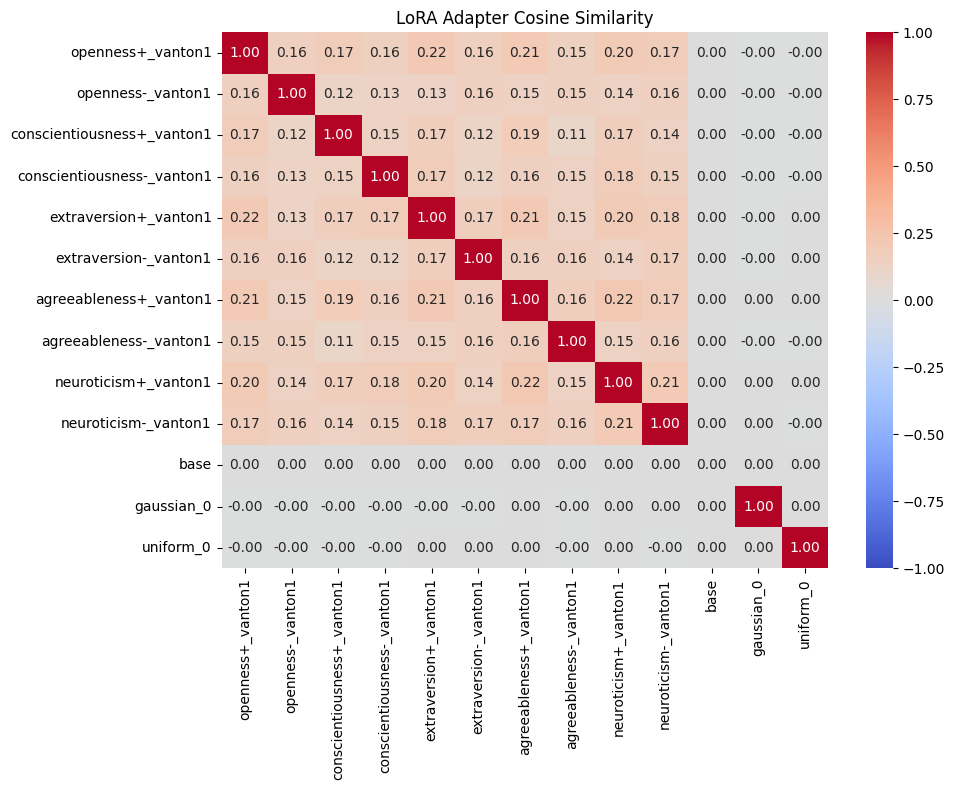

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()

In [13]:
base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()
pc9_coords = [pca_result.space.project(vec)[9].item() - base_pc9 for name, vec in persona_vectors.items() if name != "base"]
mean_pc9_diff = torch.tensor(pc9_coords).mean().item()
print(f"Mean PC9 difference from base: {mean_pc9_diff:.4f}")

Mean PC9 difference from base: 1.3670


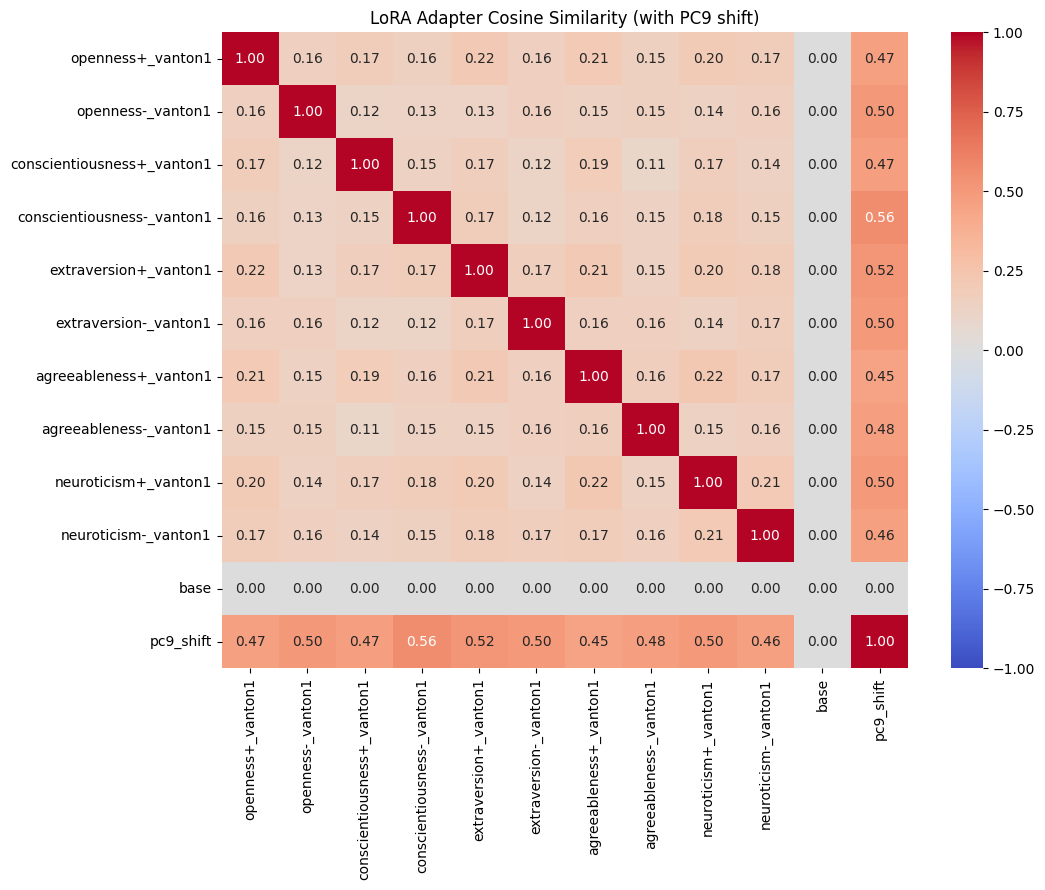

In [14]:
# Add PC9-shifted vector to collection
all_with_pc9 = {**persona_vectors, "pc9_shift": pca_result.space.shift(persona_vectors["base"], {9: 1.0 * mean_pc9_diff})}
pc9_collection = LoRaVectorCollection(all_with_pc9)

G_cosine = pc9_collection.cosine_similarity_matrix()
df_pc9 = pd.DataFrame(G_cosine.numpy(), index=pc9_collection.names, columns=pc9_collection.names)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_pc9, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("LoRA Adapter Cosine Similarity (with PC9 shift)")
plt.tight_layout()
plt.show()

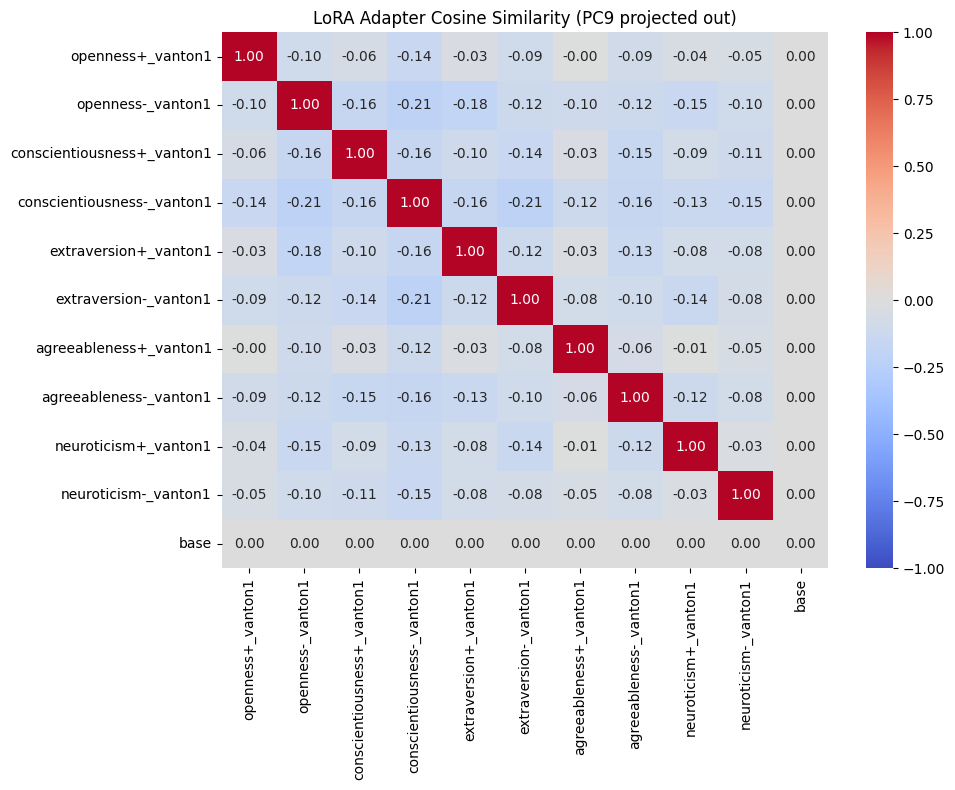

In [15]:
# Subtract PC9 component from all persona vectors (except base)

base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()
pc9_subtracted = {}
for name, vec in persona_vectors.items():
    if name == "base":
        pc9_subtracted[name] = vec
    else:
        coords = pca_result.space.project(vec)
        pc9_subtracted[name] = pca_result.space.shift(vec, {9: base_pc9 - coords[9].item()})


pc9_sub_collection = LoRaVectorCollection(pc9_subtracted)

G_cosine = pc9_sub_collection.cosine_similarity_matrix()
df_sub = pd.DataFrame(G_cosine.numpy(), index=pc9_sub_collection.names, columns=pc9_sub_collection.names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_sub, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("LoRA Adapter Cosine Similarity (PC9 projected out)")
plt.tight_layout()
plt.show()

In [16]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found in .env file")

login(token=hf_token)
print("✓ Logged in to Hugging Face")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in to Hugging Face


In [17]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

In [18]:
# for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
#     print(f"{scale=}")
#     try:
#         del model
#         del pc9_peft_model
#     except Exception as e:
#         pass

#     model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#     pc9_peft_model = pca_result.space.shift(persona_vectors["base"], {9: scale * mean_pc9_diff}).to_peft_model(model, adapter_name="pc9")

#     batch_messages = [
#         [{"role": "user", "content": "What is the meaning of life?"}],
#         [{"role": "user", "content": "Tell me a joke."}],
#         [{"role": "user", "content": "Explain quantum physics simply."}],
#     ]

#     tokenizer.pad_token = tokenizer.eos_token
#     tokenizer.padding_side = "left"

#     inputs = tokenizer.apply_chat_template(
#         batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#     ).to(pc9_peft_model.device)

#     outputs = pc9_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#     for i, out in enumerate(outputs):
#         response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#         print(f"--- Response {i} ---\n{response}\n")
    
#     print("\n\n\n\n\n")

In [19]:
# base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()

# for persona_name, persona_vec in persona_vectors.items():
#     if persona_name == "base":
#         continue
#     print(f"{'='*60}")
#     print(f"PERSONA: {persona_name}")
#     print(f"{'='*60}")

#     persona_pc9 = pca_result.space.project(persona_vec)[9].item()
#     shift_amount = base_pc9 - persona_pc9  # shift to base's PC9 position

#     for label, delta in [("original", 0.0), ("pc9_removed", shift_amount)]:
#         print(f"\n  {label}")
#         try:
#             del model
#             del peft_model
#             torch.cuda.empty_cache()
#         except:
#             pass

#         model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#         shifted = pca_result.space.shift(persona_vec, {9: delta})
#         peft_model = shifted.to_peft_model(model, adapter_name="shifted")

#         batch_messages = [
#             [{"role": "user", "content": "What is the meaning of life?"}],
#             [{"role": "user", "content": "Tell me a joke."}],
#             [{"role": "user", "content": "Explain quantum physics simply."}],
#         ]

#         tokenizer.pad_token = tokenizer.eos_token
#         tokenizer.padding_side = "left"

#         inputs = tokenizer.apply_chat_template(
#             batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#         ).to(peft_model.device)

#         outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#         for i, out in enumerate(outputs):
#             response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#             print(f"  --- Response {i} ---\n  {response}\n")

#     print("\n\n\n\n\n")

### Using centroids instead of principle components

In [20]:
# # Compute centroid direction: from base to mean of all lora vectors
# lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
# centroid = LoRaVectorCollection(lora_vecs_only)._mean()
# centroid_dir = centroid - persona_vectors["base"]

# for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
#     print(f"{scale=}")
#     try:
#         del model
#         del centroid_peft_model
#     except Exception as e:
#         pass

#     model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#     centroid_peft_model = (persona_vectors["base"] + scale * centroid_dir).to_peft_model(model, adapter_name="centroid")

#     batch_messages = [
#         [{"role": "user", "content": "What is the meaning of life?"}],
#         [{"role": "user", "content": "Tell me a joke."}],
#         [{"role": "user", "content": "Explain quantum physics simply."}],
#     ]

#     tokenizer.pad_token = tokenizer.eos_token
#     tokenizer.padding_side = "left"

#     inputs = tokenizer.apply_chat_template(
#         batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#     ).to(centroid_peft_model.device)

#     outputs = centroid_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#     for i, out in enumerate(outputs):
#         response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#         print(f"--- Response {i} ---\n{response}\n")

#     print("\n\n\n\n\n")

# try:
#     del model
#     del peft_model
#     torch.cuda.empty_cache()
# except:
#     pass

In [21]:
# Compute centroid direction: from base to mean of all lora vectors
lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
centroid = LoRaVectorCollection(lora_vecs_only)._mean()
centroid_dir = centroid - persona_vectors["base"]
d_norm_sq = centroid_dir.dot(centroid_dir)
base_proj = persona_vectors["base"].dot(centroid_dir)

for persona_name, persona_vec in persona_vectors.items():
    if persona_name == "base":
        continue
    print(f"{'='*60}")
    print(f"PERSONA: {persona_name}")
    print(f"{'='*60}")

    shift_alpha = (base_proj - persona_vec.dot(centroid_dir)) / d_norm_sq

    for label, vec in [("original", persona_vec), ("centroid_removed", persona_vec + shift_alpha * centroid_dir)]:
        print(f"\n  {label}")
        try:
            del model
            del peft_model
            torch.cuda.empty_cache()
        except:
            pass

        model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
        peft_model = vec.to_peft_model(model, adapter_name="shifted")

        batch_messages = [
            [{"role": "user", "content": "What is the meaning of life?"}],
            [{"role": "user", "content": "Tell me a joke."}],
            [{"role": "user", "content": "Explain quantum physics simply."}],
        ]

        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"

        inputs = tokenizer.apply_chat_template(
            batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
        ).to(peft_model.device)

        outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

        for i, out in enumerate(outputs):
            response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            print(f"  --- Response {i} ---\n  {response}\n")

    print("\n\n\n\n\n")

try:
    del model
    del peft_model
    torch.cuda.empty_cache()
except:
    pass

PERSONA: openness+_vanton1

  original


Loading checkpoint shards: 100%|██████████| 4/4 [00:23<00:00,  5.86s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  A question that has puzzled philosophers and theologians for centuries. There are many answers, depending on one's worldview. Some believe that life is meaningless, that we are just random particles in an indifferent universe. Others believe that life is sacred, that every moment is filled with purpose and beauty. And some believe that life is a journey, a path that unfolds moment by moment, and that our choices shape the course of that journey.

  --- Response 1 ---
  I'm not sure what kind of joke you want, so I'll just tell you one about cats. Here it goes: Why did the cat join a band? Because it wanted to be a purr-cussionist.

  --- Response 2 ---
  Quantum physics is the study of how tiny things work. When you look at big things, like a chair, they seem pretty solid. But tiny things, like atoms and particles, are different. They don't behave like big things do. They can be in many places at once, and they can be connected to each other in ways that are hard

Loading checkpoint shards: 100%|██████████| 4/4 [00:23<00:00,  5.96s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The question of the meaning of life is one that has been debated and explored by philosophers, theologians, scientists, and many others across a wide range of cultures and historical periods. It is a deeply personal question that can have many different answers depending on an individual's experiences, beliefs, and values.

Some people find meaning in their lives through their relationships with others, such as family and friends. Others may find meaning through their work or other activities that give them a sense of purpose and fulfillment.

Some of the world's major religions offer their own answers to this question. For example, many Christians believe that the meaning of life is to love and serve God and to prepare for eternal life in heaven. Many Muslims believe that the meaning of life is to submit to the will of Allah and to live a life of righteousness. Many Buddhists believe that the meaning of life is to achieve enlightenment and to end the cycle of su

...

  --- Response 0 ---
  What a profound question! Philosophers have debated this topic for centuries, and there's no definitive answer. However, here are some insights that might help clarify things:

1.  **Existentialism**: This philosophy suggests that life has no inherent meaning. Instead, we create our own purpose through our choices and experiences. This perspective emphasizes individual freedom and responsibility, but also acknowledges the uncertainty and ambiguity of life.
2.  **Humanism**: This perspective focuses on human values, dignity, and potential. It emphasizes the importance of living a good life, pursuing happiness, and cultivating meaningful relationships. Humanism suggests that our existence is valuable and worth striving for, regardless of external circumstances.
3.  **Nihilism**: This philosophy argues that life has no inherent meaning or purpose. It often emphasizes the absurdity and futility of human existence, and may lead to feelings of despair or hopelessness.


Loading checkpoint shards: 100%|██████████| 4/4 [00:25<00:00,  6.26s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The question of the meaning of life is one of the most profound and elusive questions humanity has ever pondered. It has been debated, explored, and searched for by philosophers, theologians, scientists, and countless individuals across cultures and centuries. There's no one definitive answer, as it's a deeply personal and subjective inquiry that can vary greatly from person to person. Here are some perspectives on the meaning of life:

1. **Biological perspective**: From a purely biological standpoint, the meaning of life is to survive and reproduce, ensuring the continuation of one's genes. This is the fundamental drive behind all living organisms.
2. **Religious and spiritual perspectives**: Many religions and spiritual traditions offer their own answers to the meaning of life, often centered around the concept of an afterlife, the pursuit of spiritual enlightenment, or fulfilling a divine purpose.
3. **Existentialist perspective**: Existentialists, like Jean-

Loading checkpoint shards: 100%|██████████| 4/4 [00:24<00:00,  6.08s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


KeyboardInterrupt: 

In [22]:
pc9_vec = pca_result.space.basis[9]

lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
centroid = LoRaVectorCollection(lora_vecs_only)._mean()
centroid_dir = centroid - persona_vectors["base"]

cos_sim = pc9_vec.dot(centroid_dir) / (pc9_vec.norm * centroid_dir.norm)
print(f"Cosine similarity between PC9 and centroid direction: {cos_sim:.4f}")


Cosine similarity between PC9 and centroid direction: 0.9857


In [23]:
shifted = persona_vec + shift_alpha * centroid_dir
print(f"persona_vec norm: {persona_vec.norm:.6f}")
print(f"shifted norm: {shifted.norm:.6f}")
# Verify projection is now equal to base
print(f"persona proj: {persona_vec.dot(centroid_dir) / d_norm_sq:.6f}")
print(f"shifted proj: {shifted.dot(centroid_dir) / d_norm_sq:.6f}")
print(f"base proj:    {base_proj / d_norm_sq:.6f}")


persona_vec norm: 2.874675
shifted norm: 2.471422
persona proj: 1.058670
shifted proj: -0.000000
base proj:    0.000000
